# Análisis y validación de datos - Online Shop 2024

## 1. Introducción 

### 1.1 Objetivo del proyecto 

Analizar un conjunto de datos de comercio electrónico mediante técnicas de perfilado, validación y limpieza utilizando Python y Pandas, con el fin de identificar características estructurales, asi como problemas de calidad e integridad de los datos antes de ser utilizados en procesos posteriores de transformación, modelado y análisis SQL.

### 1.2 Técnologías utilizadas
- Python
- Pandas
- PostgreSQL
- Jupyter Notebook
- Visual Studio Code


## 2. Carga y preparación de los datos

### 2.1 Importación de librerías


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Entorno:", sys.executable)

Python: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]
Pandas: 3.0.5
NumPy: 2.5.2
Entorno: /Users/citlalli/Documents/projects/.venv/bin/python


### 2.2 Carga de los archivos CSV

In [2]:
customers = pd.read_csv("../data/raw/customers.csv")
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
products = pd.read_csv("../data/raw/products.csv")
suppliers = pd.read_csv("../data/raw/suppliers.csv")
payments = pd.read_csv("../data/raw/payment.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")
shipments = pd.read_csv("../data/raw/shipments.csv")

### 2.3 Diccionario de DataFrames

In [3]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "suppliers": suppliers,
    "payments": payments,
    "reviews": reviews,
    "shipments": shipments
}

## 3. Perfilado de tablas

### 3.1 Objetivo

Analizar la estructura general del conjunto de datos considerando el número de registros (filas), atributos (columnas), valores nulos, registros duplicados y memoria utilizada.

### 3.2 Código

In [4]:
profiling = []

for name, df in tables.items():
    profiling.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "null_values": df.isna().sum().sum(), # sum por columna y suma total
        "duplicate_rows": df.duplicated().sum(), # filas completas idénticas
        "memory_mb": round(df.memory_usage(deep = True).sum() / (1024 ** 2), 2)
    })

profiling_df = pd.DataFrame(profiling)


### 3.3 Resultados

Los resultados obtenidos del perfilado de tablas son:

In [5]:
profiling_df

,table,rows,columns,null_values,duplicate_rows,memory_mb
0,customers,10000,6,0,0,3.14
1,orders,15000,4,0,0,1.19
2,order_items,20000,5,0,0,0.76
3,products,2000,5,0,0,0.28
4,suppliers,100,6,0,0,0.03
5,payments,15000,5,0,0,2.02
6,reviews,1106,6,0,0,0.18
7,shipments,15000,7,0,0,4.31


In [8]:
# Confirmación número de filas y columnas
print(column_profiling_df.shape)

# Total de registros
print(profiling_df["rows"].sum())

(44, 14)
78206


### 3.4 Observaciones
- El conjunto de datos está compuesto por 8 tablas y 78,206 registros.
- Los registros totales varían según la naturaleza de cada tabla.
- No se presentan valores nulos.
- No se presentan filas duplicadas.

## 4. Perfilado de columnas

### 4.1 Objetivo

Conocer las características de cada una de las columnas presentes en el conjunto de datos, incluyendo su tipo de dato, valores nulos, cardinalidad y estadísticas, con el fin de detectar posibles problemas de calidad y preparar los datos para las etapas posteriores de transformación, modelado y análisis SQL.

### 4.2 Código

In [6]:
column_profiling = []

for table_name, df in tables.items():

    for column in df.columns:
        series = df[column]

        profile = {
            "table": table_name,
            "column": column,
            "dtype": str(series.dtype),
            "non_null": series.notna().sum(),
            "null": series.isna().sum(),
            "unique_values": series.nunique(dropna = True),
            "duplicate_values": series.duplicated().sum()
        }

        # Estadísticas para columnas numéricas
        if pd.api.types.is_numeric_dtype(series):
            profile["min"] = series.min()
            profile["q1"] = series.quantile(0.25)
            profile["median"] = series.median()
            profile["q3"] = series.quantile(0.75)
            profile["max"] = series.max()
            profile["mean"] = series. mean()
            profile["std"] = series.std()

        else:
            profile["min"] = np.nan
            profile["q1"] = np.nan
            profile["median"] = np.nan
            profile["q3"] = np.nan
            profile["max"] = np.nan 
            profile["mean"] = np.nan
            profile["std"] = np.nan

        column_profiling.append(profile)

column_profiling_df = pd.DataFrame(column_profiling)

# Redondear valores para las columnas numéricas
numeric_columns = [
    "min",
    "q1",
    "median",
    "q3",
    "max",
    "mean",
    "std"
]
column_profiling_df[numeric_columns] = (
    column_profiling_df[numeric_columns].round(2)
)

### 4.3 Resultados

Los resultados obtenidos del perfilado de columnas son:

In [7]:
column_profiling_df 

,table,column,dtype,non_null,null,unique_values,duplicate_values,min,q1,median,q3,max,mean,std
0,customers,customer_id,int64,10000,0,10000,0,1.00,2500.75,5000.50,7500.25,10000.00,5000.50,2886.90
1,customers,first_name,str,10000,0,3,9997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,customers,last_name,str,10000,0,70,9930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,customers,address,str,10000,0,59,9941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,customers,email,str,10000,0,10000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,customers,phone_number,str,10000,0,9995,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,orders,order_id,int64,15000,0,15000,0,1.00,3750.75,7500.50,11250.25,15000.00,7500.50,4330.27
7,orders,order_date,str,15000,0,366,14634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,orders,customer_id,int64,15000,0,10000,5000,1.00,2477.75,4974.50,7476.00,10000.00,4982.94,2886.07
9,orders,total_price,float64,15000,0,14741,259,20.46,932.52,2207.06,4249.19,10082.72,2833.05,2275.53


### 4.4 Observaciones

- No se presentan valores nulos.
- Los tipos de datos encontrados son `int64`, `str` y `float64`. 
- Existen columnas en las cuales los valores de  `non_null` y `unique_values` son identicos. 
- Las columnas con valores idénticos en `non_null` y `unique_values` pueden ser consideradas como posibles claves primarias.

In [9]:
# Guardar perfilados en archivos formato CSV
profiling_df.to_csv(
    "../reports/01_table_profiling.csv",
    index=False)

column_profiling_df.to_csv(
    "../reports/02_column_profiling.csv",
    index=False
)

## 5. Validación de claves primarias

### 5.1 Objetivo

Conocer que columnas del conjunto de datos cumplen con las condiciones de unicidad y ausencia de valores nulos para ser consideradas claves primarias.

### 5.2 Posibles claves primarias

De acuerdo con los resultados del perfilado de columnas las posibles claves primarias de cada tabla del conjunto de datos son:

| Tabla | Primary Key |
|---|---|
| `customers` | `customer_id` |
| `orders` | `order_id` |
| `order_items` | `order_item_id` |
| `products` | `product_id` |
| `suppliers` | `supplier_id` |
| `payments` | `payment_id` |
| `reviews` | `review_id` |
| `shipments` | `shipment_id` |

### 5.3 Código

In [10]:
pk_columns = {
    "customers": "customer_id",
    "orders": "order_id",
    "order_items": "order_item_id",
    "products": "product_id",
    "suppliers": "supplier_id",
    "payments": "payment_id",
    "reviews": "review_id",
    "shipments": "shipment_id"
}

pk_validation = []

for table_name, pk in pk_columns.items():

    df = tables[table_name]

    pk_validation.append({
        "table": table_name,
        "primary_key": pk,
        "rows": len(df),
        "unique_values": df[pk].nunique(),
        "null_values": df[pk].isna().sum(),
        "duplicate_values": df[pk].duplicated().sum(),
        "is_unique": df[pk].is_unique
    })

pk_validation_df = pd.DataFrame(pk_validation)

### 5.4 Resultados

Los resultados de la validacion son:

In [11]:
pk_validation_df

,table,primary_key,rows,unique_values,null_values,duplicate_values,is_unique
0,customers,customer_id,10000,10000,0,0,True
1,orders,order_id,15000,15000,0,0,True
2,order_items,order_item_id,20000,20000,0,0,True
3,products,product_id,2000,2000,0,0,True
4,suppliers,supplier_id,100,100,0,0,True
5,payments,payment_id,15000,15000,0,0,True
6,reviews,review_id,1106,1106,0,0,True
7,shipments,shipment_id,15000,15000,0,0,True


### 5.5 Observaciones

- No se presentan valores nulos.
- No se presentan valores duplicados.
- El total de registros y valores únicos son idénticos.
- Todas las columnas analizadas cumple con el criterio de unicidad.

## 6. Validación de claves foráneas

### 6.1 Objetivo

Comprobar las relaciones entre las tablas del conjunto de datos.

### 6.2 Relaciones identificadas

Las siguientes relaciones entre tablas serán validadas utilizando las claves foráneas identificadas:

| Tabla hija | Foreign Key | Tabla padre | Primary Key |
|---|---|---|---|
| `orders` | `customer_id` | `customers` | `customer_id` |
| `order_items` | `order_id` | `orders` | `order_id` |
| `order_items` | `product_id` | `products` | `product_id` |
| `products` | `supplier_id` | `suppliers` | `supplier_id` |
| `payments` | `order_id` | `orders` | `order_id` |
| `shipments` | `order_id` | `orders` | `order_id` |
| `reviews` | `product_id` | `products` | `product_id` |
| `reviews` | `customer_id` | `customers` | `customer_id` |

### 6.3 Código

In [12]:
fk_relationships = [
    ("orders", "customer_id", "customers", "customer_id"),
    ("order_items", "order_id", "orders", "order_id"),
    ("order_items", "product_id", "products", "product_id"),
    ("products", "supplier_id", "suppliers", "supplier_id"),
    ("payments", "order_id", "orders", "order_id"),
    ("shipments", "order_id", "orders", "order_id"),
    ("reviews", "product_id", "products", "product_id"),
    ("reviews", "customer_id", "customers", "customer_id")
]

fk_validation = []

for child_table, fk, parent_table, pk in fk_relationships:

    child_df = tables[child_table]
    parent_df = tables[parent_table]

    matches = child_df[fk].isin(parent_df[pk]) #¿Cada valor de la FK de la tabla hija existe en la PK de la tabla padre?

    fk_validation.append({
        "child_table": child_table,
        "foreign_key": fk,
        "parent_table": parent_table,
        "primary_key": pk,
        "fk_values": child_df[fk].nunique(),
        "orphan_records": (~matches).sum(),
        "referential_integrity": matches.all()
    })

fk_validation_df = pd.DataFrame(fk_validation)

### 6.4 Resultados

Los resultados de la validación de las claves foráneas son:


In [13]:
fk_validation_df

,child_table,foreign_key,parent_table,primary_key,fk_values,orphan_records,referential_integrity
0,orders,customer_id,customers,customer_id,10000,0,True
1,order_items,order_id,orders,order_id,15000,0,True
2,order_items,product_id,products,product_id,1997,0,True
3,products,supplier_id,suppliers,supplier_id,100,0,True
4,payments,order_id,orders,order_id,15000,0,True
5,shipments,order_id,orders,order_id,15000,0,True
6,reviews,product_id,products,product_id,158,0,True
7,reviews,customer_id,customers,customer_id,553,0,True


### 6.5 Observaciones

- No se identificaron registros huérfanos en ninguna de las claves foráneas (`orphan_records = 0`).
- Todos los valores de las claves foráneas tienen correspondencia con las respectivas claves primarias.
- La columna `order_items.product_id` presenta 1,997 valores distintos, aunque la tabla `products` contiene 2,000 productos. Esto indica que no todos los productos disponibles tienen registros asociados en `order_items`.
- Las columnas `reviews.product_id` y `reviews.customer_id` presentan menos valores que el número total de productos y clientes disponibles, lo cual indica que solamente una parte de los productos y clientes cuenta con registros de reseñas.
- Las ocho relaciones evaluadas presentan integridad referencial.

### 6.5 Conclusión

La validación de claves foráneas confirma que las relaciones definidas en el modelo de datos mantienen la integridad referencial, ya que no se identificaron registros huérfanos y todas las claves foráneas evaluadas tienen correspondencia con sus respectivas claves primarias.

## 7. Validación de tipos de datos

### 7.1 Objetivo

Verificar que los tipos de datos de las columnas sean adecuados y consistentes con la información que representan, con el fin de facilitar los procesos posteriores de transformación, análisis y consulta SQL.

### 7.2 Código

In [14]:
dtype_validation = []

for table_name, df in tables.items():

    for column in df.columns:

        dtype_validation.append({
            "table": table_name,
            "column": column,
            "dtype": str(df[column].dtype)
        })

dtype_validation_df = pd.DataFrame(dtype_validation)

### 7.3 Resultados

Los tipos de datos actualmente asignados a cada atributo de las ocho tablas se presentan a continuacion:

In [15]:
dtype_validation_df

,table,column,dtype
0,customers,customer_id,int64
1,customers,first_name,str
2,customers,last_name,str
3,customers,address,str
4,customers,email,str
5,customers,phone_number,str
6,orders,order_id,int64
7,orders,order_date,str
8,orders,customer_id,int64
9,orders,total_price,float64


### 7.4 Observaciones

- Los identificadores, cantidades y puntuaciones se encuentran almacenados como tipo entero (`int64`).
- Los precios y valores monetarios se encuentran almacenados como tipo flotante (`float64`).
- Los atributos descriptivos se encuentran almacenados como cadena de texto (`str`).
- Se identificaron cuatro atributos temporales almacenados como tipo cadena de texto (`str`): `orders.order_date`, `reviews.review_date`, `shipments.shipment_date` y `shipments.delivery_date`.
- El tipo de dato de los atributos temporales deberá convertirse a tipo fecha y hora (`datetime`) para facilitar el filtrado, ordenamiento y análisis posterior.

## 8. Validación de valores numéricos

### 8.1 Objetivo

Analizar la distribución de los atributos numéricos e identificar posibles valores atípicos o inconsistencias mediante medidas estadísticas como los valores mínimo y máximo, cuartiles, mediana y rango intercuartílico (IQR).

### 8.2 Código

In [16]:
numeric_columns_for_outliers = {
    "orders": ["total_price"],
    "order_items": ["quantity", "price_at_purchase"],
    "products": ["price"],
    "payments": ["amount"],
    "reviews": ["rating"]
}

outlier_analysis = []

for table_name, columns in numeric_columns_for_outliers.items():

    df = tables[table_name]

    for column in columns:

        series = df[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outliers = series[
            (series < lower_limit) |
            (series > upper_limit)
        ]

        outlier_analysis.append({
            "table": table_name,
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_limit": lower_limit,
            "upper_limit": upper_limit,
            "outlier_count": len(outliers)
        })

outlier_analysis_df = pd.DataFrame(outlier_analysis)

### 8.3 Resultados

Se calcularon los límites inferior y superior mediante el método del rango intercuartílico (IQR) para identificar posibles valores atípicos en los atributos numéricos.

In [17]:
outlier_analysis_df

,table,column,q1,q3,iqr,lower_limit,upper_limit,outlier_count
0,orders,total_price,932.5200,4249.1850,3316.6650,-4042.47750,9224.18250,111
1,order_items,quantity,2.0000,7.0000,5.0000,-5.50000,14.50000,0
2,order_items,price_at_purchase,32.1100,675.1425,643.0325,-932.43875,1639.69125,0
3,products,price,250.4600,751.6450,501.1850,-501.31750,1503.42250,0
4,payments,amount,75.2925,603.2000,527.9075,-716.56875,1395.06125,0
5,reviews,rating,1.0000,4.0000,3.0000,-3.50000,8.50000,0


### 8.4 Observaciones

- El análisis mediante el rango intercuartílico (IQR) identificó posibles valores atípicos únicamente en el atributo `orders.total_price`.
- Se identificaron 111 registros potencialmente atípicos en `orders.total_price`.
- El límite superior calculado para `orders.total_price` fue de aproximadamente 9,224.18.
- Los límites estadísticos negativos obtenidos en algunas variables no representan valores presentes en los datos, sino el resultado matemático del método IQR.
- La identificación de un valor atípico no implica que el registro sea incorrecto. Los posibles outliers deberán analizarse considerando las reglas y el contexto del negocio antes de decidir si requieren tratamiento.


## 9. Validación de reglas de negocio

### 9.1 Objetivo

El objetivo de esta etapa es verificar que los atributos cuantitativos cumplan con las restricciones esperadas de acuerdo con su significado dentro del modelo de datos.

### 9.2 Reglas evaluadas

| Tabla | Atributo | Regla |
|---|---|---|
| `orders` | `total_price` | `>= 0` |
| `order_items` | `quantity` | `>= 0` |
| `order_items` | `price_at_purchase` | `>= 0` |
| `products` | `price` | `>= 0` |
| `payments` | `amount` | `>= 0` |
| `reviews` | `rating` | Entre 1 y 5 |

### 9.3 Código

In [18]:
business_rules = [
    ("orders", "total_price", ">= 0"),
    ("order_items", "quantity", ">= 0"),
    ("order_items", "price_at_purchase", ">= 0"),
    ("products", "price", ">= 0"),
    ("payments", "amount", ">= 0"),
    ("reviews", "rating", "between 1 and 5")
]

business_validation = []

for table_name, column, rule in business_rules:

    series = tables[table_name][column]

    if rule == ">= 0":
        invalid_records = (series < 0).sum()

    elif rule == "between 1 and 5":
        invalid_records = ((series < 1) | (series > 5)).sum()

    business_validation.append({
        "table": table_name,
        "column": column,
        "rule": rule,
        "invalid_records": invalid_records,
        "valid": invalid_records == 0
    })

business_validation_df = pd.DataFrame(business_validation)

### 9.4 Resultados

Se evaluaron reglas de negocio básicas para los atributos relacionados con precios, cantidades, montos monetarios y calificaciones.

In [19]:
business_validation_df

,table,column,rule,invalid_records,valid
0,orders,total_price,>= 0,0,True
1,order_items,quantity,>= 0,0,True
2,order_items,price_at_purchase,>= 0,0,True
3,products,price,>= 0,0,True
4,payments,amount,>= 0,0,True
5,reviews,rating,between 1 and 5,0,True


### 9.4 Observaciones

- No se identificaron registros con valores negativos en `total_price`, `quantity`, `price_at_purchase`, `price` ni `amount`.
- Todas las calificaciones de `reviews.rating` se encuentran dentro del rango esperado de 1 a 5.
- Las seis reglas de negocio evaluadas presentan `valid = True`.
- Los resultados indican que los atributos cuantitativos analizados cumplen con las reglas de validación establecidas.

## 10. Limpieza y transformación de datos

### 10.1 Objetivo

El objetivo de esta etapa es corregir y estandarizar los datos identificados durante el perfilado, preparando las tablas para su posterior carga, modelado y análisis mediante SQL.

### 10.2 Conversión de atributos temporales

| Tabla | Atributo | Tipo actual | Tipo esperado |
|---|---|---|---|
| `orders` | `order_date` | `str` | `datetime` |
| `reviews` | `review_date` | `str` | `datetime` |
| `shipments` | `shipment_date` | `str` | `datetime` |
| `shipments` | `delivery_date` | `str` | `datetime` |

### 10.3 Código

In [20]:
date_columns = {
    "orders": ["order_date"],
    "reviews": ["review_date"],
    "shipments": ["shipment_date", "delivery_date"]
}

for table_name, columns in date_columns.items():
    for column in columns:
        tables[table_name][column] = pd.to_datetime(
            tables[table_name][column],
            errors="coerce"
        )

### 10.3 Verificar la transformación

In [21]:
date_type_validation = []

for table_name, columns in date_columns.items():
    for column in columns:
        date_type_validation.append({
            "table": table_name,
            "column": column,
            "dtype": tables[table_name][column].dtype
        })

date_type_validation_df = pd.DataFrame(date_type_validation)

### 10.4 Resultados

Los cuatro atributos temporales identificados durante el perfilado fueron convertidos correctamente de `str` a `datetime64[us]`, permitiendo su utilización en operaciones de análisis temporal.

In [22]:
date_type_validation_df

,table,column,dtype
0,orders,order_date,datetime64[us]
1,reviews,review_date,datetime64[us]
2,shipments,shipment_date,datetime64[us]
3,shipments,delivery_date,datetime64[us]


### 10.4 Validación de valores NaT

Se verificó que la conversión de los atributos temporales no generara valores `NaT`, los cuales representan fechas que no pudieron convertirse correctamente.

In [23]:
for table_name, columns in date_columns.items():
    for column in columns:
        print(
            table_name,
            column,
            "NaT:",
            tables[table_name][column].isna().sum()
        )

orders order_date NaT: 0
reviews review_date NaT: 0
shipments shipment_date NaT: 0
shipments delivery_date NaT: 0


**Observación:** La conversión de los atributos temporales no generó valores NaT, por lo que no se identificaron fechas inválidas durante la transformación.

## 11. Exportación de datos limpios

### 11.1 Objetivo

Exportar las tablas después de las transformaciones realizadas durante el proceso de limpieza, conservando la estructura original y los tipos de datos corregidos.

In [24]:
import os

os.makedirs("../data/clean", exist_ok=True)

for table_name, df in tables.items():
    df.to_csv(
        f"../data/clean/{table_name}.csv",
        index=False
    )

### 11.2 Resultado

Las ocho tablas fueron exportadas correctamente a la carpeta `data/clean/`.

Los archivos originales se conservaron en `data/raw/` y los archivos transformados se almacenaron en `data/clean/`, manteniendo una separación entre los datos originales y los datos preparados para las siguientes etapas del proyecto.

## 12. Análisis de los datos




**Objetivo:** identificar el número de pedidos y el gasto total de cada cliente.

La consulta relaciona las tablas `customers` y `orders` mediante `customer_id`. Se utiliza `LEFT JOIN` para conservar todos los clientes, incluso aquellos que no tengan pedidos.

- `COUNT()` calcula el número de pedidos.
- `SUM()` calcula el gasto total.
- `COALESCE()` reemplaza valores `NULL` por `0`.
- `GROUP BY` agrupa la información por cliente.
- `ORDER BY` permite ordenar los clientes de mayor a menor gasto.

**Resultado:** se obtiene un resumen del comportamiento de compra de cada cliente.

### 12.1 Clientes con mayor gasto

Los tres clientes con mayor gasto registrado presentan únicamente dos pedidos
cada uno. Sin embargo, sus gastos acumulados superan los $17,000.

Esto indica que un gasto total elevado no necesariamente está relacionado con
una mayor cantidad de pedidos. Para determinar qué factores explican estos
montos sería necesario analizar el valor y composición de los productos
incluidos en sus pedidos.

**Top 3 clientes por gasto:**

1. John Williams — 2 pedidos — $19,651.70
2. James Natalie — 2 pedidos — $17,567.00
3. John Philip — 2 pedidos — $17,124.03

### 12.2 Segmentación de clientes

De los 10,000 clientes analizados, 4,255 (42.55%) pertenecen al segmento
Bajo, 3,850 (38.50%) al segmento Medio y 1,895 (18.95%) al segmento Alto.

El 81.05% de los clientes se concentra en los segmentos Bajo y Medio,
mientras que el segmento Alto representa 18.95% del total.

Esta distribución puede ser útil para identificar oportunidades de
segmentación y analizar posteriormente qué características de los pedidos
están asociadas con un mayor gasto.

**Distribución:**

- Bajo: 4,255 clientes (42.55%)
- Medio: 3,850 clientes (38.50%)
- Alto: 1,895 clientes (18.95%)

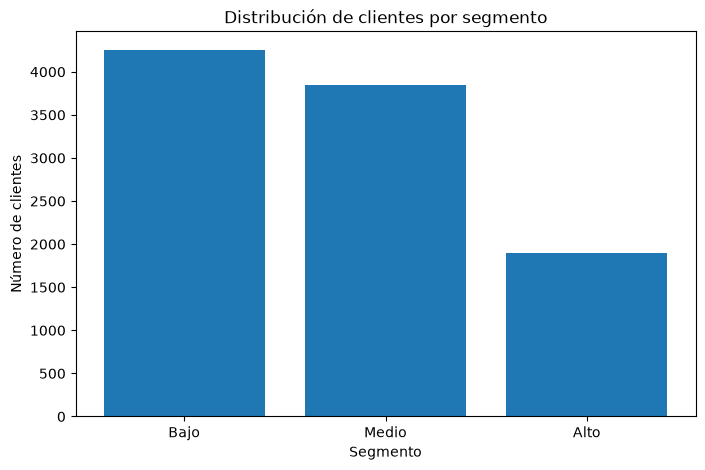

In [25]:

segments = ['Bajo', 'Medio', 'Alto']
customers = [4255, 3850, 1895]

plt.figure(figsize=(8, 5))
plt.bar(segments, customers)

plt.title('Distribución de clientes por segmento')
plt.xlabel('Segmento')
plt.ylabel('Número de clientes')

plt.show()

### 12.3 Productos con mayor ingreso

El producto con mayor ingreso registrado es `Water Bottle`, perteneciente a
la categoría `Home & Kitchen`, con $63,822.93 generados a partir de 92
unidades vendidas.

Al comparar unidades e ingresos, se observa que el producto con mayor
cantidad de unidades vendidas dentro del Top 10 no necesariamente es el
producto con mayor ingreso. Por ejemplo, `Wireless Mouse` registra 118
unidades vendidas y $53,935.18 de ingresos, mientras que `Water Bottle`
genera $63,822.93 con 92 unidades.

También se identificaron tres registros diferentes con el nombre `Standing
Desk` (`product_id` 1186, 936 y 986). Esto demuestra la importancia de utilizar
`product_id` como identificador para distinguir productos y evitar agrupar
registros únicamente por nombre.

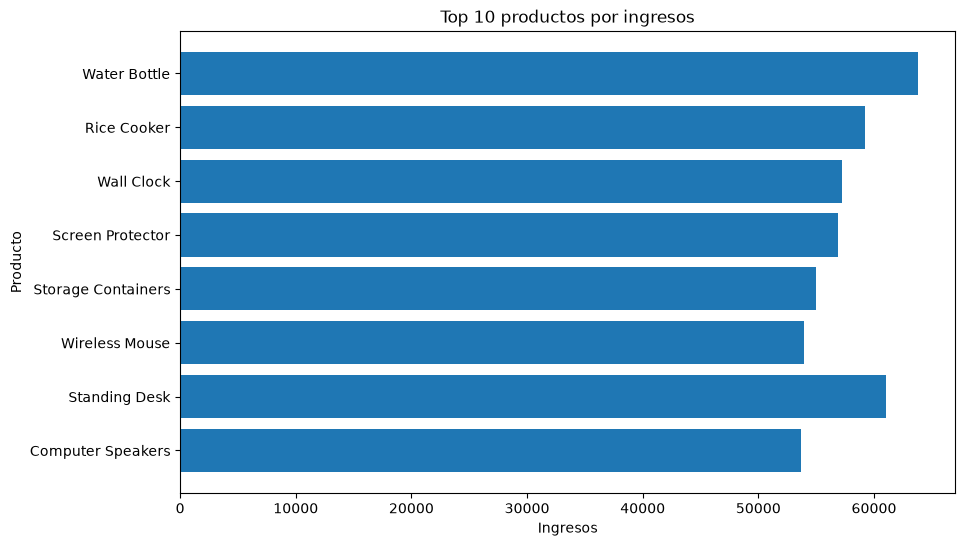

In [26]:
products = [
    'Water Bottle',
    'Standing Desk',
    'Rice Cooker',
    'Wall Clock',
    'Screen Protector',
    'Standing Desk',
    'Storage Containers',
    'Wireless Mouse',
    'Standing Desk',
    'Computer Speakers'
]

revenue = [
    63822.93,
    61073.42,
    59233.99,
    57196.17,
    56872.60,
    55811.02,
    55027.95,
    53935.18,
    53684.79,
    53674.71
]

plt.figure(figsize=(10, 6))
plt.barh(products[::-1], revenue[::-1])

plt.title('Top 10 productos por ingresos')
plt.xlabel('Ingresos')
plt.ylabel('Producto')

plt.show()

### 12.4 Producto líder por categoría

Mediante `RANK()` y `PARTITION BY category` se identificó el producto con
mayor ingreso dentro de cada categoría.

Los productos líderes fueron:

- Accessories: `Screen Protector` — $56,872.60
- Electronics: `Wireless Mouse` — $53,935.18
- Furniture: `Standing Desk` — $61,073.42
- Home & Kitchen: `Water Bottle` — $63,822.93

Entre los productos líderes, `Water Bottle` presenta el mayor ingreso con
$63,822.93, seguido por `Standing Desk` con $61,073.42.

Este análisis permite identificar los productos de mayor rendimiento dentro
de cada categoría. Sin embargo, estos resultados no representan los ingresos
totales de cada categoría, ya que solamente consideran el producto que ocupa
el primer lugar en cada una.

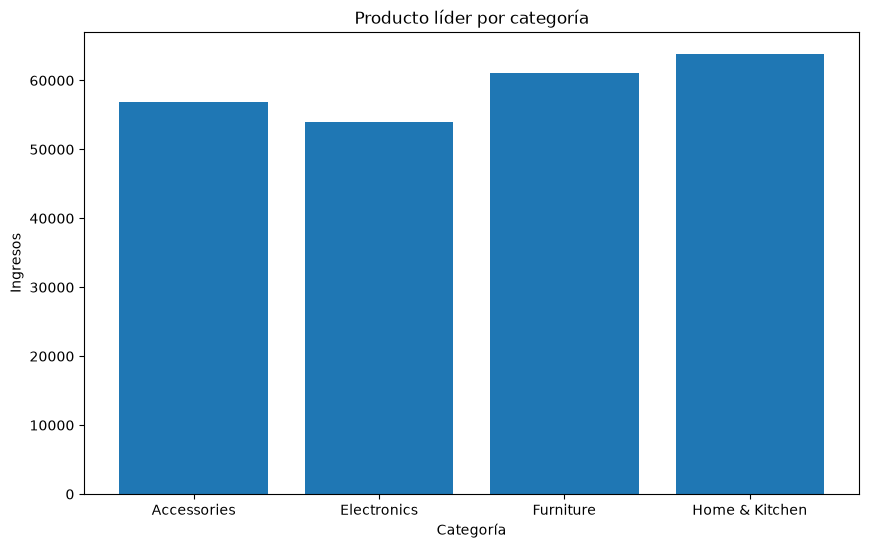

In [27]:
categories = [
    'Accessories',
    'Electronics',
    'Furniture',
    'Home & Kitchen'
]

revenue = [
    56872.60,
    53935.18,
    61073.42,
    63822.93
]

plt.figure(figsize=(10, 6))
plt.bar(categories, revenue)

plt.title('Producto líder por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ingresos')


plt.show()

## 13. Conclusiones

El análisis de los datos del e-commerce permitió identificar diferentes patrones relacionados con el comportamiento de los clientes y el desempeño de los productos.

**1. Comportamiento de los clientes**

Los clientes con mayor gasto acumulado no necesariamente son los que realizan más pedidos. Los tres clientes con mayor gasto registrado tienen únicamente dos pedidos cada uno. Esto muestra que el valor de las compras puede tener un mayor impacto en el gasto total que la cantidad de pedidos realizados.

**2. Segmentación de clientes**

La segmentación basada en el gasto acumulado muestra que el 42.55% de los clientes pertenece al segmento Bajo, el 38.50% al segmento Medio y el 18.95% al segmento Alto.

En conjunto, el 81.05% de los clientes pertenece a los segmentos Bajo o Medio, mientras que el 18.95% corresponde al segmento Alto.

**3. Desempeño de los productos**

El producto con mayor ingreso acumulado fue el *Water Bottle*, con $63,822.93 en ingresos y 92 unidades vendidas.

Por otro lado, el *Wireless Mouse* registró 118 unidades vendidas, pero generó $53,935.18 en ingresos. Esto demuestra que vender una mayor cantidad de unidades no necesariamente significa generar mayores ingresos, ya que el precio de venta también influye en el resultado.

**4. Identificación de productos**

El análisis también mostró que existen diferentes productos con el mismo nombre, como *Standing Desk*. Por esta razón, el `product_id` debe utilizarse como identificador principal para distinguir productos y evitar agrupar registros diferentes únicamente por su nombre.

**5. Aplicación de SQL**

El proyecto permitió aplicar diferentes herramientas de SQL para resolver problemas de análisis de datos, entre ellas:

* `JOIN` y `LEFT JOIN` para relacionar tablas.
* `GROUP BY` para realizar agregaciones.
* `COUNT()` y `SUM()` para obtener métricas.
* `COALESCE()` para manejar valores nulos.
* `CASE WHEN` para crear segmentos.
* CTEs (`WITH`) para dividir consultas complejas en etapas.
* `RANK()` y `PARTITION BY` para realizar rankings dentro de cada categoría.
* `ORDER BY` y `LIMIT` para ordenar y seleccionar resultados relevantes.

